Jest to wersja stworzona z wykorzystaniem "gotowców".
Miała ona na celu zrozumienie i przedstawienie jak ma działać cała aplikacja.

Ostatecznie będzie to wyglądało w ten sposób:
1. Stworzyć własny dataset ze zdjęciami ubrań i maskami tych ubrań
2. Nauczyć własny model na własnym datasecie rozpoznawać ubrania na zdjęciu. Konkretniej wskazywać jego maskę, aby można było jej użyć w rozpoznawaniu kolorów i wzorów fragmentu ubioru. (U-Net)
3. Analiza kolorów na podstawie maski
4. Feedback od OpenAI na podstawie danych zebranych przez aplikacje na temat ubioru

Instalacja bibliotek

In [27]:
# Instalacja biblioteki Ultralytics
# Zawiera modele YOLO
!pip install ultralytics

# Instalacja bibliotek do semantic segmentation
!pip install transformers accelerate

Import bibliotek

In [28]:
# OpenCV - operacje na obrazach
import cv2

# W Google Colab zwykłe cv2.imshow() nie działa
# dlatego używamy cv2_imshow()
from google.colab.patches import cv2_imshow

# NumPy - operacje matematyczne na tablicach
import numpy as np

# YOLO od Ultralytics
from ultralytics import YOLO

# Biblioteki HuggingFace do segmentacji
from transformers import (
    AutoImageProcessor,
    AutoModelForSemanticSegmentation
)

# PyTorch
import torch

Wczytanie obrazu

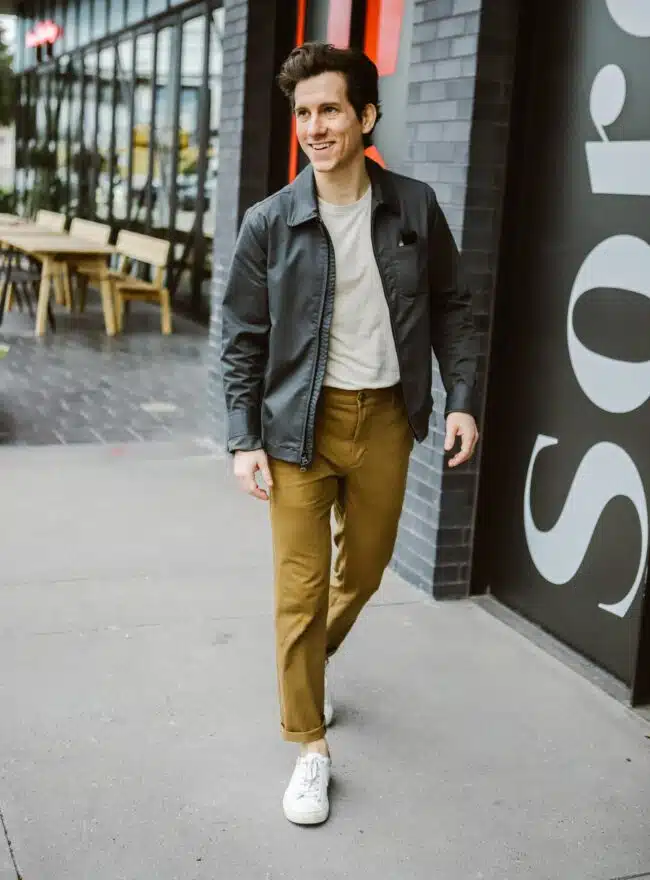

In [29]:
# Ścieżka do obrazu
image_path = "/content/drive/MyDrive/Colab Notebooks/INZ/pic.png"

# Wczytanie obrazu
img = cv2.imread(image_path)

# Jeżeli obraz się nie wczytał -> błąd
if img is None:
    raise RuntimeError(f"Nie można wczytać obrazu: {image_path}")

# Wyświetlenie obrazu
cv2_imshow(img)

OBJECT DETECTION - YOLO

In [30]:
# Wczytanie modelu YOLO
# wersja "seg" potrafi dodatkowo tworzyć maski
model_yolo = YOLO("yolov8n-seg.pt")

# Wykonanie detekcji
# conf=0.4 oznacza minimalną pewność 40%
results_yolo = model_yolo(img, conf=0.4)


0: 640x480 1 person, 1 chair, 1 dining table, 10.8ms
Speed: 2.5ms preprocess, 10.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)


Wypisanie wykrytych obiektów

In [31]:
# Iteracja po wszystkich wykrytych obiektach
for i, box in enumerate(results_yolo[0].boxes):

    # Pobranie numeru klasy
    cls = int(box.cls[0].cpu().numpy())

    # Pobranie confidence score
    conf = float(box.conf[0].cpu().numpy())

    # Pobranie współrzędnych bounding boxa
    xyxy = box.xyxy[0].cpu().numpy()

    # Nazwa klasy
    label = model_yolo.names[cls]

    print(f"Obiekt {i + 1}")
    print(f"Klasa: {label}")
    print(f"Confidence: {conf:.2f}")
    print(f"Bounding box: {xyxy}")
    print("------------------------")

Obiekt 1
Klasa: person
Confidence: 0.91
Bounding box: [     218.34       43.98      482.49      823.17]
------------------------
Obiekt 2
Klasa: chair
Confidence: 0.69
Bounding box: [     104.57      228.06      184.09      337.73]
------------------------
Obiekt 3
Klasa: dining table
Confidence: 0.43
Bounding box: [     2.0361      223.95      132.27      255.47]
------------------------


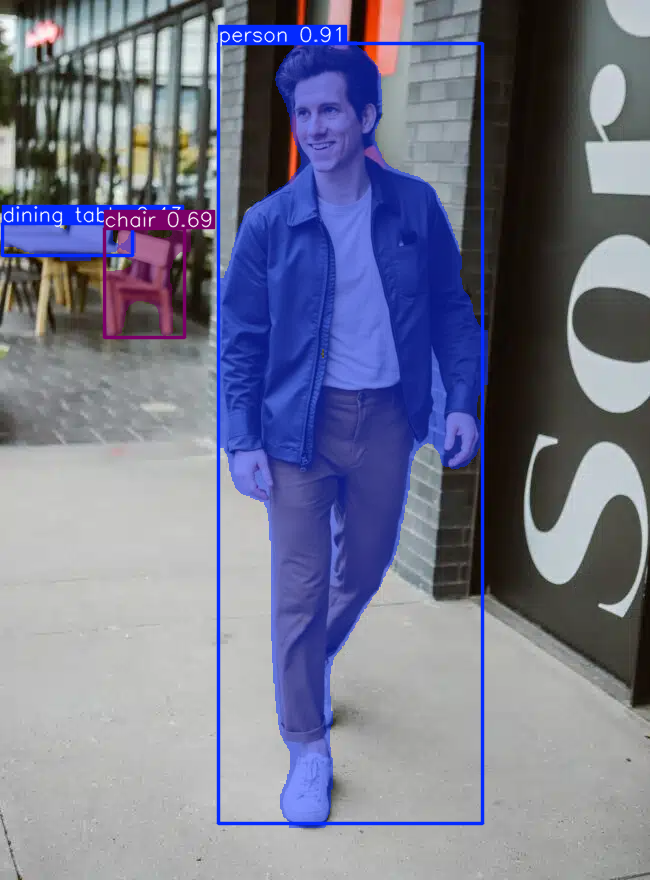

In [32]:
# results_yolo[0].plot() automatycznie:
# - rysuje bounding boxy
# - rysuje maski
# - dodaje podpisy
annotated_img = results_yolo[0].plot()

# Wyświetlenie obrazu
cv2_imshow(annotated_img)

#SEMANTIC SEGMENTATION - UBRANIA

Wczytanie modelu

In [33]:
# Processor przygotowuje obraz do modelu
processor = AutoImageProcessor.from_pretrained(
    "mattmdjaga/segformer_b2_clothes"
)

# Model semantic segmentation
model_segmentation = AutoModelForSemanticSegmentation.from_pretrained(
    "mattmdjaga/segformer_b2_clothes"
)

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

In [34]:
# Mapowanie numerów klas na nazwy
id2label = {
    0: "background",
    1: "hat",
    2: "hair",
    3: "sunglasses",
    4: "upper_clothes",
    5: "skirt",
    6: "pants",
    7: "dress",
    8: "belt",
    9: "left_shoe",
    10: "right_shoe",
    11: "face",
    12: "left_leg",
    13: "right_leg",
    14: "left_arm",
    15: "right_arm",
    16: "bag",
    17: "scarf"
}

Przygotowanie obrazu

In [35]:
# OpenCV używa BGR
# model oczekuje RGB
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Zamiana obrazu na tensor
inputs = processor(
    images=image_rgb,
    return_tensors="pt"
)

Predykcja modelu

In [36]:
# Wyłączenie gradientów
# przyspiesza inferencję
with torch.no_grad():

    # Predykcja modelu
    outputs = model_segmentation(**inputs)

Pobranie segmentacji

In [37]:
# outputs.logits zawiera prawdopodobieństwa klas
logits = outputs.logits

# Zmiana rozmiaru do rozmiaru oryginalnego obrazu
upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=image_rgb.shape[:2],
    mode="bilinear",
    align_corners=False
)

# Wybór najbardziej prawdopodobnej klasy
pred_seg = upsampled_logits.argmax(dim=1)[0]

# Zamiana na NumPy
segmentation = pred_seg.cpu().numpy()

Tworzenie masek ubrań

In [38]:
# Słownik przechowujący maski ubrań
clothing_masks = {}

# Iteracja po wszystkich klasach
for class_id, label_name in id2label.items():

    # Pomijamy background
    if label_name == "background":
        continue

    # Tworzenie maski dla danej klasy
    mask = (segmentation == class_id)

    # Jeżeli maska zawiera piksele
    if np.sum(mask) > 0:

        # Zapisanie maski
        clothing_masks[label_name] = mask

        print(f"Wykryto: {label_name}")

Wykryto: hair
Wykryto: upper_clothes
Wykryto: pants
Wykryto: left_shoe
Wykryto: right_shoe
Wykryto: face
Wykryto: right_leg
Wykryto: left_arm
Wykryto: right_arm


#FUNKCJA ROZPOZNAWANIA KOLORU

In [39]:
# Funkcja określająca dominujący kolor ubrania
# Na podstawie średniej wartości RGB

def detect_color(mean_rgb):

    # Rozdzielenie kanałów
    r, g, b = mean_rgb

    # Biały
    if r > 200 and g > 200 and b > 200:
        return "white"

    # Czarny
    elif r < 60 and g < 60 and b < 60:
        return "black"

    # Szary
    elif abs(r - g) < 20 and abs(g - b) < 20:
        return "gray"

    # Czerwony
    elif r > g and r > b:
        return "red"

    # Zielony
    elif g > r and g > b:
        return "green"

    # Niebieski
    elif b > r and b > g:
        return "blue"

    # Żółty
    elif r > 150 and g > 150 and b < 100:
        return "yellow"

    # Różowy
    elif r > 180 and b > 180:
        return "pink"

    # Brązowy
    elif r > 100 and g > 50 and b < 50:
        return "brown"

    # Jeżeli nie udało się określić
    else:
        return "unknown"

In [40]:
# Iteracja po wszystkich ubraniach
for clothing_name, mask in clothing_masks.items():

    # Pobranie pikseli należących do ubrania
    pixels = image_rgb[mask]

    # Jeżeli brak pikseli -> pomijamy
    if len(pixels) == 0:
        continue

    # Obliczenie średniego koloru RGB
    mean_color = np.mean(pixels, axis=0)

    # Rozpoznanie koloru
    detected_color = detect_color(mean_color)

    # Wyświetlenie informacji
    print(f"Ubranie: {clothing_name}")
    print(f"Kolor: {detected_color}")
    print(f"Średni RGB: {mean_color}")
    print("------------------------")

Ubranie: hair
Kolor: black
Średni RGB: [     50.559      37.646       25.02]
------------------------
Ubranie: upper_clothes
Kolor: gray
Średni RGB: [     81.402      82.591      79.719]
------------------------
Ubranie: pants
Kolor: red
Średni RGB: [     114.05      85.745      33.632]
------------------------
Ubranie: left_shoe
Kolor: white
Średni RGB: [     239.78      241.06      239.08]
------------------------
Ubranie: right_shoe
Kolor: white
Średni RGB: [     220.52       222.2      220.84]
------------------------
Ubranie: face
Kolor: red
Średni RGB: [     173.55      135.37      105.34]
------------------------
Ubranie: right_leg
Kolor: red
Średni RGB: [     199.99      180.82      153.93]
------------------------
Ubranie: left_arm
Kolor: red
Średni RGB: [     175.46      147.66      132.78]
------------------------
Ubranie: right_arm
Kolor: red
Średni RGB: [      202.1      178.53      164.01]
------------------------


Wizualizacja masek

Maska dla: hair


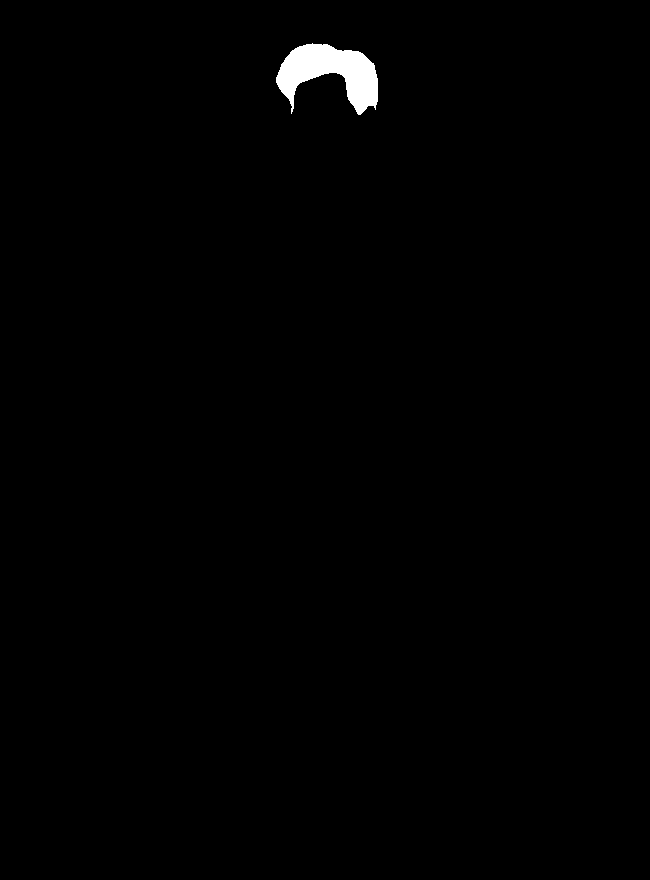

Maska dla: upper_clothes


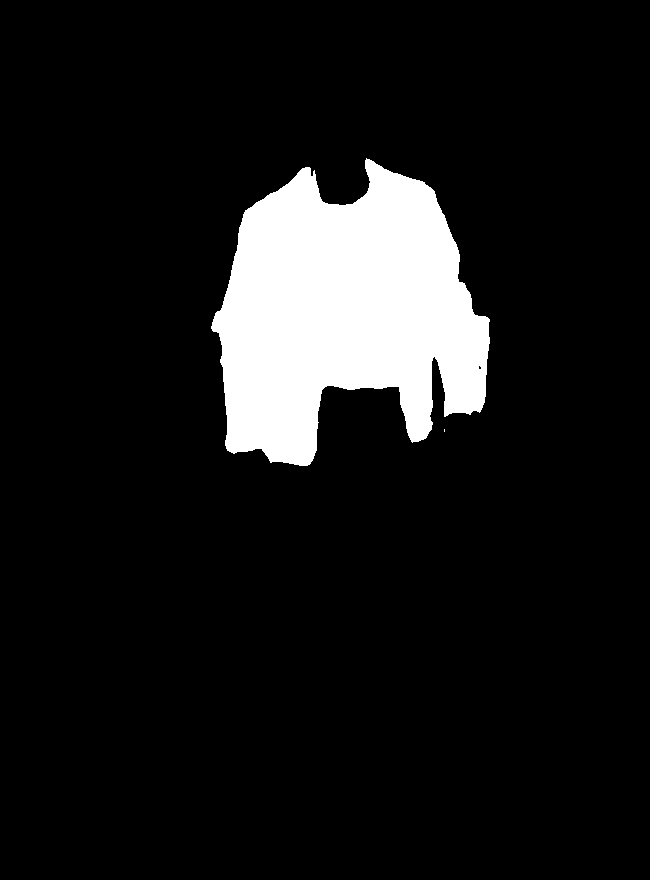

Maska dla: pants


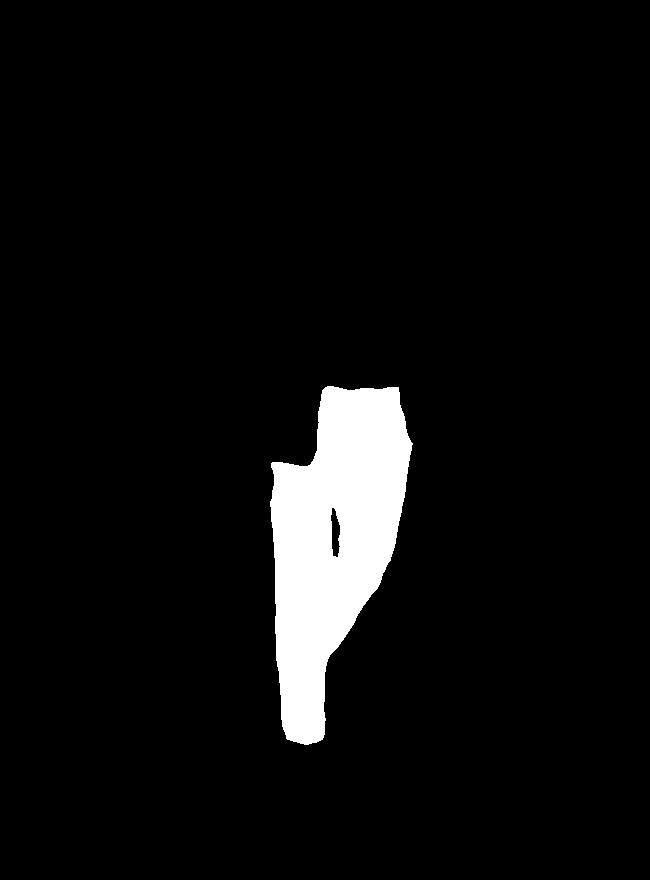

Maska dla: left_shoe


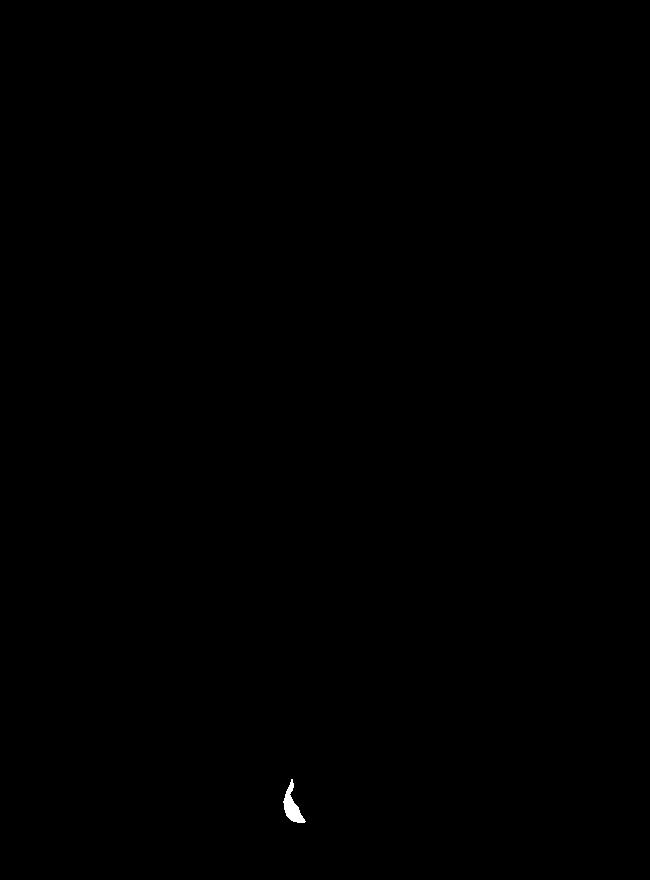

Maska dla: right_shoe


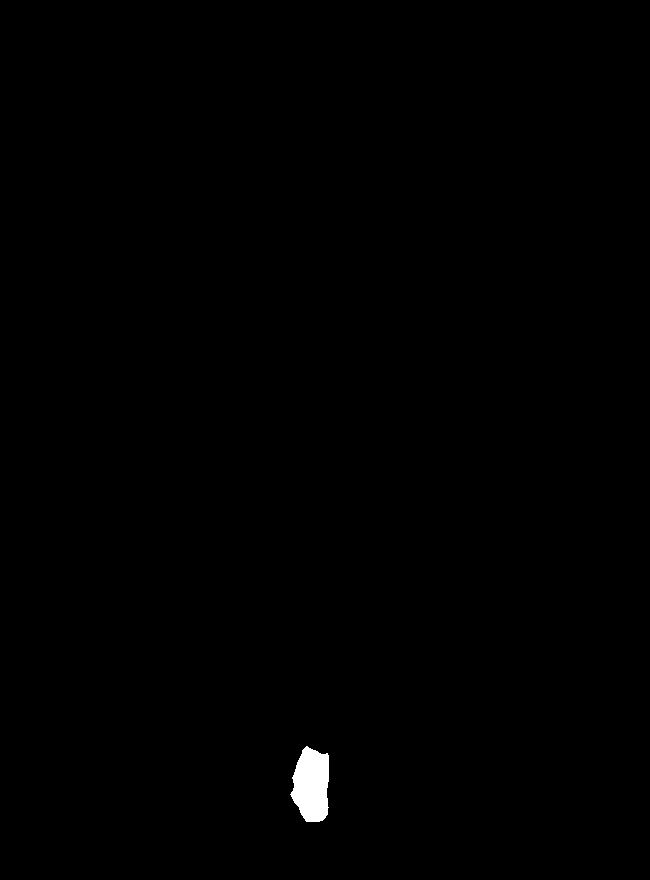

Maska dla: face


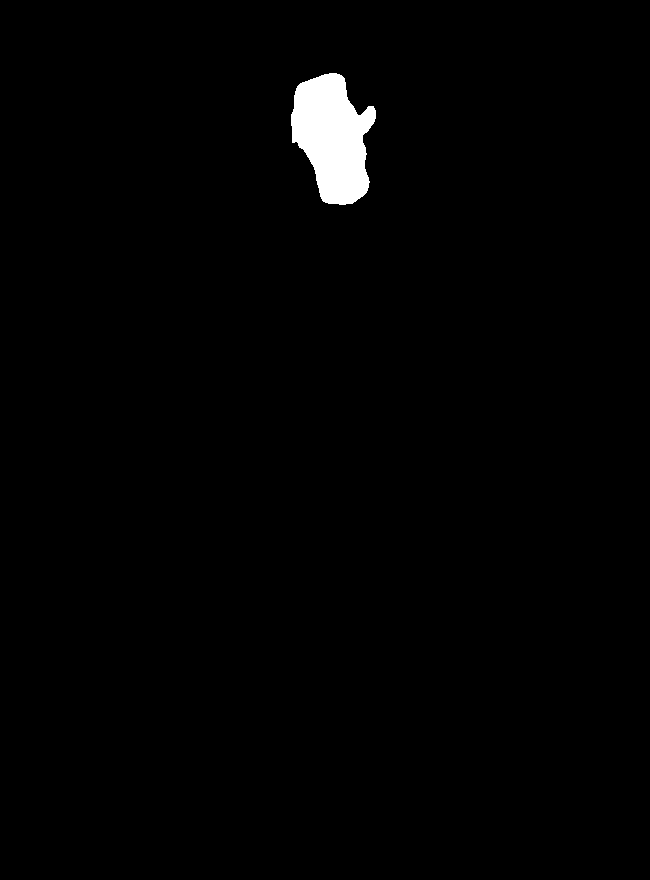

Maska dla: right_leg


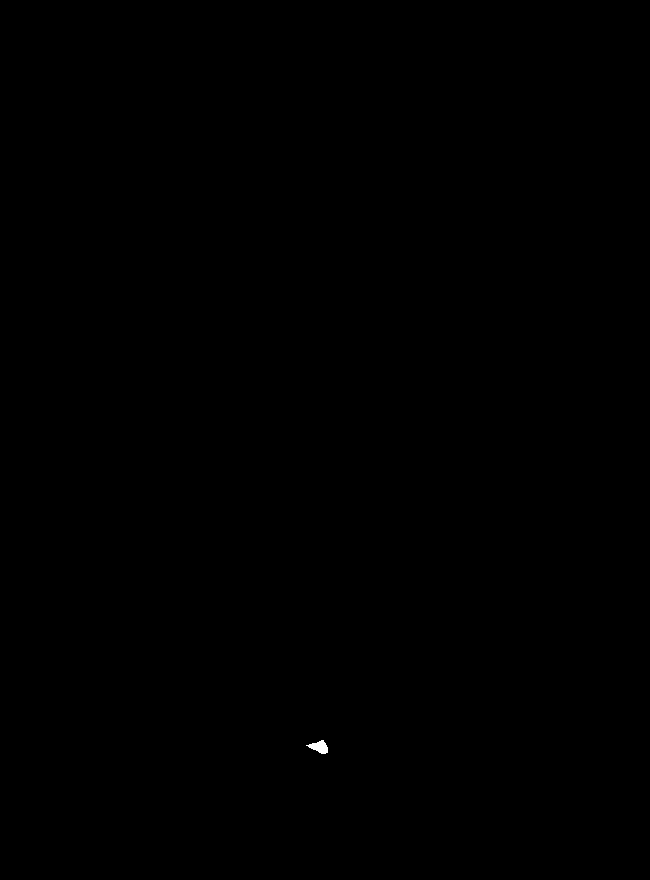

Maska dla: left_arm


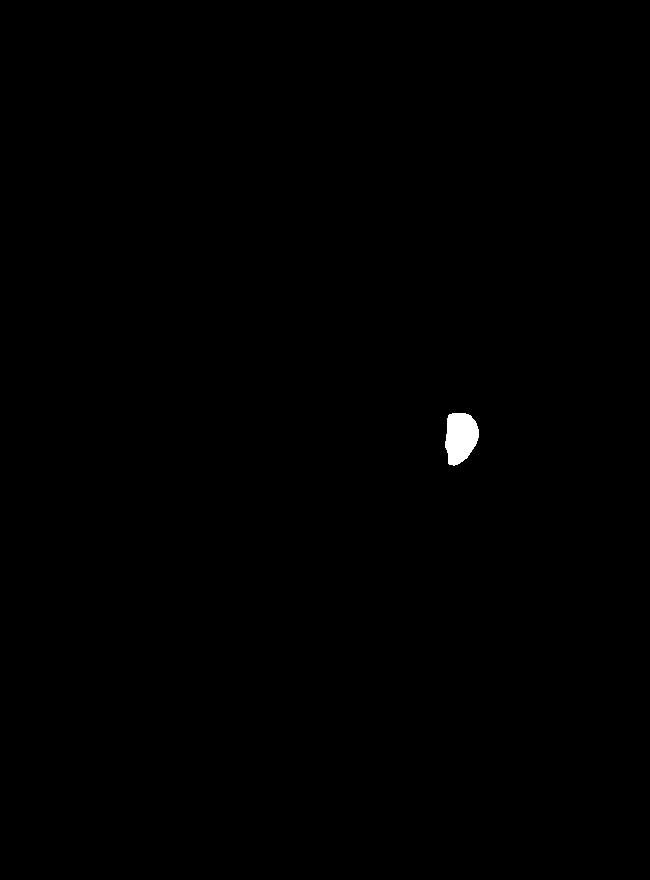

Maska dla: right_arm


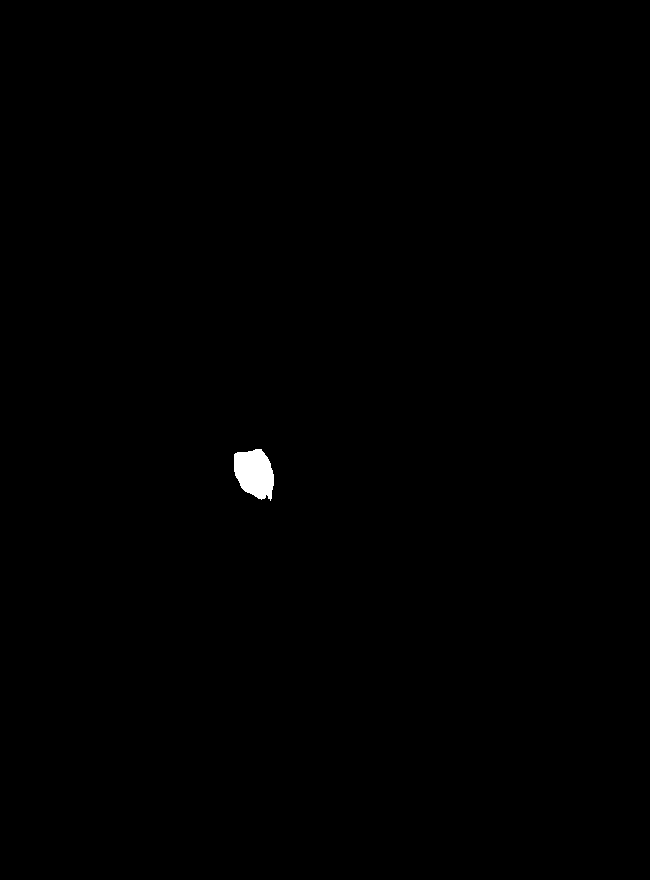

In [41]:
# Wyświetlenie każdej maski osobno
for clothing_name, mask in clothing_masks.items():

    print(f"Maska dla: {clothing_name}")

    # Zamiana bool -> uint8
    mask_uint8 = (mask.astype(np.uint8)) * 255

    # Wyświetlenie maski
    cv2_imshow(mask_uint8)